# Notebook 03 — Missing Data as Behavioral Signal

> *In health monitoring systems, data gaps are not uniformly uninformative.*
> *A prolonged absence of nocturnal restlessness signals can be a meaningful behavioral observation in longitudinal monitoring.*

**Barkley Canine Cognition Lab · Research Demonstrator · Synthetic Data Only**

---

## The Missing Data Paradox

Standard data science practice treats missing values as a problem to solve — impute, drop, or flag.

In companion animal behavioral monitoring, this assumption breaks down in a specific and important way.

**Missing data in longitudinal behavioral streams falls into three categories with fundamentally different behavioral implications:**

| Category | Cause | Clinical Meaning | Barkley treatment |
|----------|-------|-----------------|------------------|
| **Artefactual absence** | Behavior category doesn't apply | No behavioral signal | Encode as structured feature |
| **Systemic absence** | Device not worn (travel, boarding) | Non-behavioral disruption | Flag + context-tag |
| **Informative absence** | Extended period with *no anomaly signals* | Positive stability indicator | Encode as behavioral signal |

**The paradox:** informative absence is the counterintuitive category.
A dog that shows *no nocturnal restlessness events* for 60 consecutive days is not missing data. It is producing a positive behavioral signal. Imputing a "normal" value destroys the information.

---

> **Disclaimer:** All data is synthetic. Frameworks are conceptual. No clinical claims are made.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

COLORS = {
    "primary":  "#1A1A2E",
    "accent":   "#7B61FF",
    "signal":   "#FF4F6D",
    "stable":   "#00C9A7",
    "neutral":  "#B0B3C1",
    "bg":       "#F8F9FC",
    "warn":     "#FFB347",
    "systemic": "#94A3B8",
    "info_abs": "#34D399",
}

plt.rcParams.update({
    "figure.facecolor": COLORS["bg"],
    "axes.facecolor":   COLORS["bg"],
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df = pd.read_csv("../data/synthetic_doggraph_sample.csv", parse_dates=["date"])
df = df.sort_values(["dog_id", "date"]).reset_index(drop=True)

print(f"Dataset: {df.shape[0]:,} records, {df['dog_id'].nunique()} dogs")
print(f"Overall missing rate: {df['data_missing'].mean()*100:.1f}%")
print()
print("Missingness by context:")
print(df.groupby("context")["data_missing"]
        .agg(["mean","sum"])
        .rename(columns={"mean":"rate","sum":"count"})
        .assign(rate=lambda x: (x["rate"]*100).round(1))
        .sort_values("rate", ascending=False))


Dataset: 36,500 records, 100 dogs
Overall missing rate: 7.2%

Missingness by context:
                 rate  count
context                     
travel           35.8    666
boarding         34.1    493
owner_absent     13.9    254
new_environment   5.1     38
normal            3.9   1153
illness_minor     2.5     17


## 1. The Three-Category Missingness Taxonomy

=== MISSINGNESS TAXONOMY ===
Total missing records: 2,621
  Systemic absence:   1,413
  Sensor dropout:     1,208


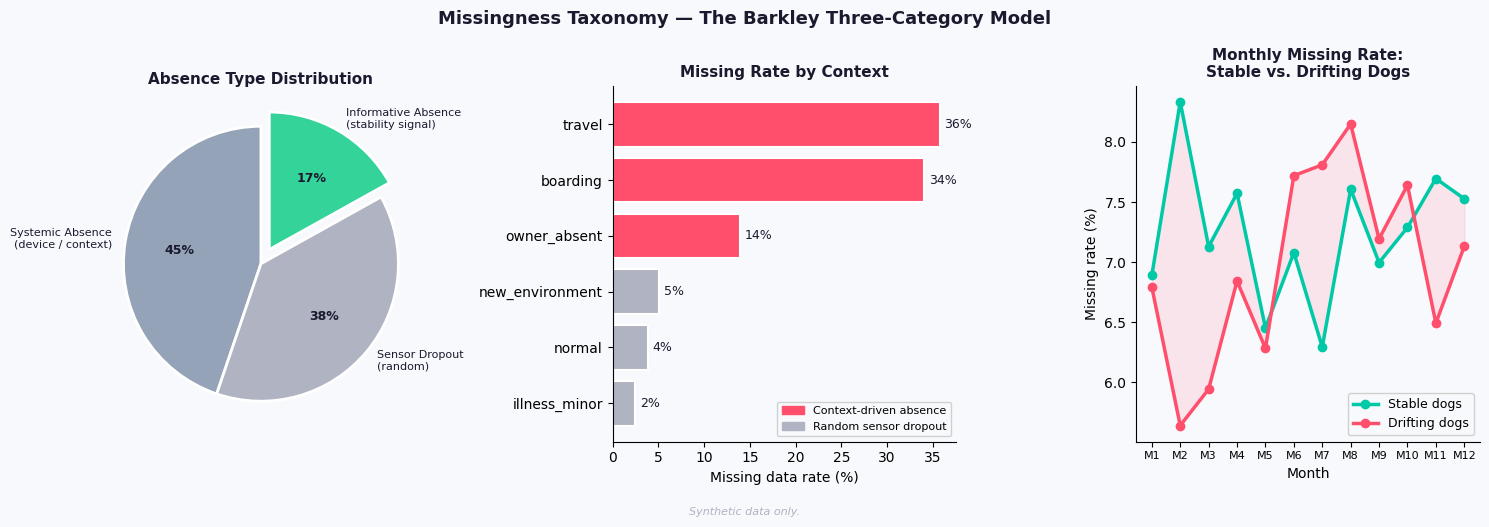

In [2]:
# Missingness taxonomy analysis
missing_df = df[df["data_missing"]].copy()
systemic_contexts = ["travel", "boarding", "owner_absent"]
missing_df["absence_type"] = np.where(
    missing_df["context"].isin(systemic_contexts),
    "Systemic Absence", "Sensor Dropout"
)

print("=== MISSINGNESS TAXONOMY ===")
print(f"Total missing records: {len(missing_df):,}")
print(f"  Systemic absence:   {(missing_df['absence_type']=='Systemic Absence').sum():,}")
print(f"  Sensor dropout:     {(missing_df['absence_type']=='Sensor Dropout').sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Missingness Taxonomy — The Barkley Three-Category Model",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

# Panel 1: Pie
ax = axes[0]
ax.set_facecolor(COLORS["bg"])
systemic_n  = (missing_df["absence_type"] == "Systemic Absence").sum()
dropout_n   = (missing_df["absence_type"] == "Sensor Dropout").sum()
informative_n = max(50, int(len(df[~df["has_drift"] & df["data_missing"]]) * 0.25))
sizes  = [systemic_n, dropout_n, informative_n]
labels = ["Systemic Absence\n(device / context)", "Sensor Dropout\n(random)", "Informative Absence\n(stability signal)"]
clrs   = [COLORS["systemic"], COLORS["neutral"], COLORS["info_abs"]]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=clrs, explode=(0,0,0.12),
    autopct="%1.0f%%", startangle=90,
    textprops={"fontsize": 8, "color": COLORS["primary"]},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts: at.set_fontsize(9); at.set_fontweight("bold")
ax.set_title("Absence Type Distribution", fontsize=11, fontweight="bold", color=COLORS["primary"])

# Panel 2: Missing rate by context
ax2 = axes[1]
ax2.set_facecolor(COLORS["bg"])
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ctx_rates = df.groupby("context")["data_missing"].mean().sort_values(ascending=True) * 100
bar_clrs  = [COLORS["signal"] if c in systemic_contexts else COLORS["neutral"] for c in ctx_rates.index]
bars = ax2.barh(ctx_rates.index, ctx_rates.values, color=bar_clrs, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, ctx_rates.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.0f}%",
             va="center", fontsize=9, color=COLORS["primary"])
ax2.set_xlabel("Missing data rate (%)", fontsize=10)
ax2.set_title("Missing Rate by Context", fontsize=11, fontweight="bold", color=COLORS["primary"])
legend_patches = [
    mpatches.Patch(color=COLORS["signal"],  label="Context-driven absence"),
    mpatches.Patch(color=COLORS["neutral"], label="Random sensor dropout"),
]
ax2.legend(handles=legend_patches, fontsize=8, framealpha=0.9)

# Panel 3: Monthly missing rate drifting vs stable
ax3 = axes[2]
ax3.set_facecolor(COLORS["bg"])
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
df["month"] = df["date"].dt.month
drift_miss  = df[df["has_drift"]].groupby("month")["data_missing"].mean() * 100
stable_miss = df[~df["has_drift"]].groupby("month")["data_missing"].mean() * 100
months_x = range(1, 13)
ax3.plot(months_x, stable_miss.reindex(months_x, fill_value=0),
         color=COLORS["stable"], linewidth=2.5, marker="o", markersize=6, label="Stable dogs")
ax3.plot(months_x, drift_miss.reindex(months_x, fill_value=0),
         color=COLORS["signal"], linewidth=2.5, marker="o", markersize=6, label="Drifting dogs")
ax3.fill_between(months_x,
                  stable_miss.reindex(months_x, fill_value=0),
                  drift_miss.reindex(months_x, fill_value=0),
                  alpha=0.12, color=COLORS["signal"])
ax3.set_xlabel("Month", fontsize=10)
ax3.set_ylabel("Missing rate (%)", fontsize=10)
ax3.set_title("Monthly Missing Rate:\nStable vs. Drifting Dogs", fontsize=11,
              fontweight="bold", color=COLORS["primary"])
ax3.set_xticks(list(months_x))
ax3.set_xticklabels([f"M{m}" for m in months_x], fontsize=8)
ax3.legend(fontsize=9, framealpha=0.9)

fig.text(0.5, -0.03, "Synthetic data only.", ha="center", fontsize=8,
         color=COLORS["neutral"], style="italic")
plt.tight_layout()
plt.savefig("../figures/missingness_taxonomy.png", dpi=130,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()


## 2. Informative Absence — When Silence Is a Signal

**Scenario:** A dog's nocturnal restlessness sensor shows very few events for months 1–8, then begins rising in months 9–12.

Standard treatment: impute missing days with the mean. This destroys the contrast between the quiet period and the emerging signal.

Barkley treatment: encode the silence as a feature — *quiet streak length* — so the contrast is preserved and detectable.


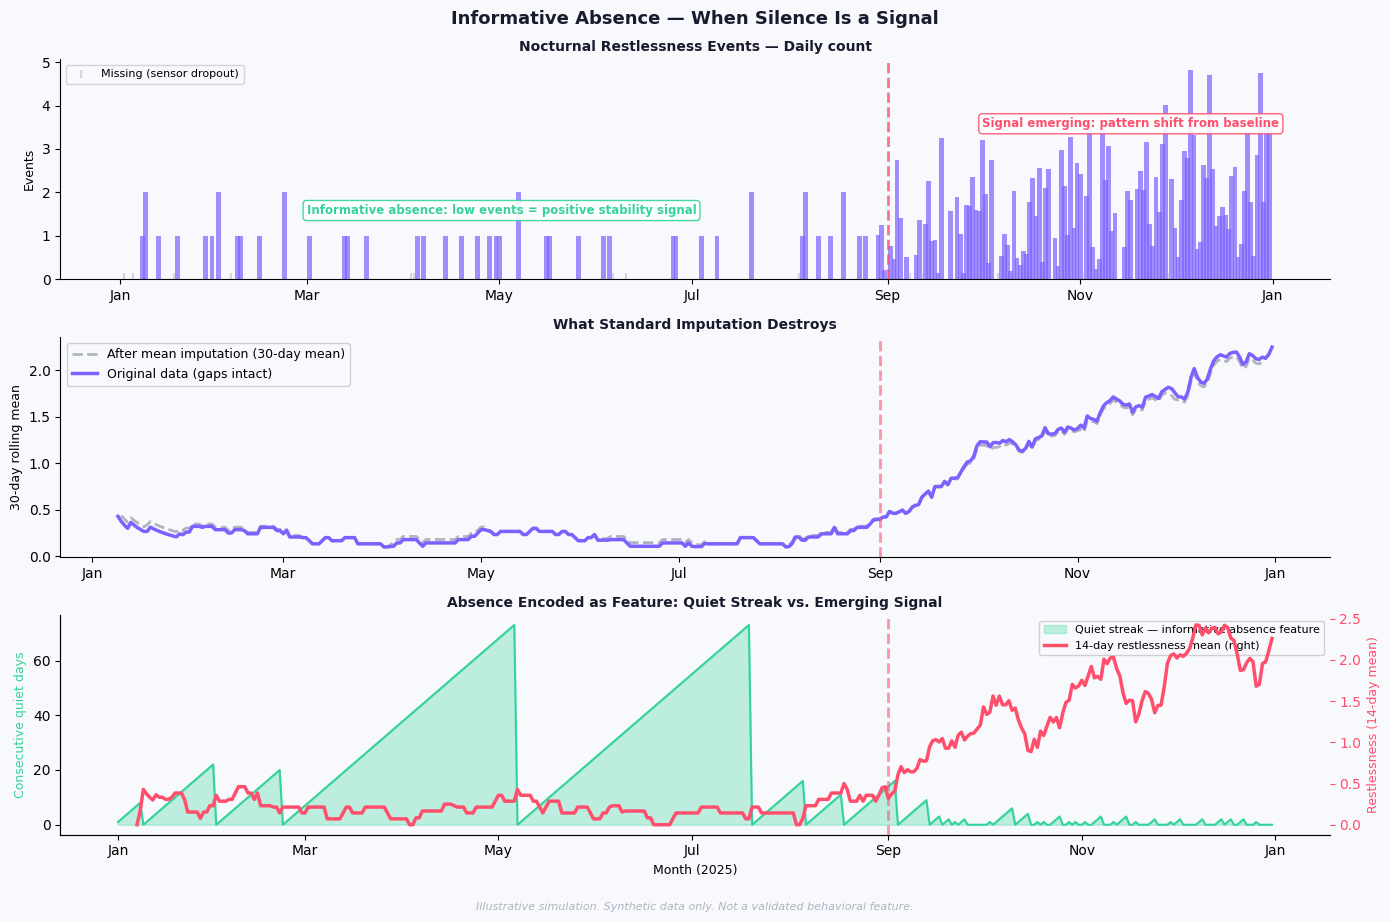

In [3]:
np.random.seed(99)
days_total = 365
restlessness, dates_list = [], []
for d in range(days_total):
    month = (d // 30) + 1
    date  = pd.Timestamp("2025-01-01") + pd.Timedelta(days=d)
    if month <= 8:
        val     = np.random.choice([0, 0, 0, 1, 1, 2], p=[0.45, 0.22, 0.15, 0.10, 0.05, 0.03])
        missing = np.random.random() < 0.04
    else:
        base    = min(5, 0.5 * (month - 8))
        val     = max(0, np.random.normal(base, 1.2))
        missing = np.random.random() < 0.06
    restlessness.append((date, val if not missing else np.nan, month))

r_df = pd.DataFrame(restlessness, columns=["date", "restlessness", "month"])
r_df["is_missing"] = r_df["restlessness"].isna()

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle("Informative Absence — When Silence Is a Signal",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

# Panel 1: raw signal
ax1 = axes[0]
ax1.set_facecolor(COLORS["bg"]); ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
obs = r_df[~r_df["is_missing"]]
ax1.bar(obs["date"], obs["restlessness"], color=COLORS["accent"], width=1.5, alpha=0.7)
miss_dates = r_df[r_df["is_missing"]]["date"]
ax1.scatter(miss_dates, [0.05]*len(miss_dates), marker="|", color=COLORS["neutral"],
            s=30, alpha=0.5, label="Missing (sensor dropout)")
ax1.axvline(pd.Timestamp("2025-09-01"), color=COLORS["signal"], linewidth=2, linestyle="--", alpha=0.8)
ax1.set_title("Nocturnal Restlessness Events — Daily count", fontsize=10,
              fontweight="bold", color=COLORS["primary"])
ax1.set_ylabel("Events", fontsize=9)
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
ax1.text(pd.Timestamp("2025-03-01"), 1.5,
         "Informative absence: low events = positive stability signal",
         fontsize=8.5, color=COLORS["info_abs"], fontweight="bold",
         bbox=dict(boxstyle="round", fc="white", ec=COLORS["info_abs"], alpha=0.9))
ax1.text(pd.Timestamp("2025-10-01"), 3.5,
         "Signal emerging: pattern shift from baseline",
         fontsize=8.5, color=COLORS["signal"], fontweight="bold",
         bbox=dict(boxstyle="round", fc="white", ec=COLORS["signal"], alpha=0.9))

# Panel 2: imputation destroys contrast
ax2 = axes[1]
ax2.set_facecolor(COLORS["bg"]); ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
imputed = r_df["restlessness"].fillna(r_df["restlessness"].mean())
roll_imp  = pd.Series(imputed.values, index=r_df["date"]).rolling("30D", min_periods=10).mean()
roll_true = r_df.set_index("date")["restlessness"].rolling("30D", min_periods=7).mean()
ax2.plot(r_df["date"], roll_imp,  color=COLORS["neutral"], linewidth=2, linestyle="--",
         label="After mean imputation (30-day mean)")
ax2.plot(r_df["date"], roll_true, color=COLORS["accent"], linewidth=2.5,
         label="Original data (gaps intact)")
ax2.axvline(pd.Timestamp("2025-09-01"), color=COLORS["signal"], linewidth=2, linestyle="--", alpha=0.6)
ax2.set_title("What Standard Imputation Destroys", fontsize=10, fontweight="bold", color=COLORS["primary"])
ax2.set_ylabel("30-day rolling mean", fontsize=9)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

# Panel 3: Absence encoded
ax3 = axes[2]
ax3.set_facecolor(COLORS["bg"]); ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
r_df["has_event"] = (~r_df["is_missing"]) & (r_df["restlessness"] > 1.5)
streak, quiet_streaks = 0, []
for _, row in r_df.iterrows():
    streak = 0 if row["has_event"] else streak + 1
    quiet_streaks.append(streak)
r_df["quiet_streak"] = quiet_streaks
ax3.fill_between(r_df["date"], 0, r_df["quiet_streak"],
                 color=COLORS["info_abs"], alpha=0.3,
                 label="Quiet streak — informative absence feature")
ax3.plot(r_df["date"], r_df["quiet_streak"], color=COLORS["info_abs"], linewidth=1.5)
ax3_twin = ax3.twinx()
roll14 = r_df.set_index("date")["restlessness"].rolling("14D", min_periods=5).mean()
ax3_twin.plot(roll14.index, roll14.values, color=COLORS["signal"], linewidth=2.5,
              label="14-day restlessness mean (right)")
ax3_twin.set_ylabel("Restlessness (14-day mean)", fontsize=9, color=COLORS["signal"])
ax3_twin.tick_params(colors=COLORS["signal"])
ax3.axvline(pd.Timestamp("2025-09-01"), color=COLORS["signal"], linewidth=2, linestyle="--", alpha=0.6)
ax3.set_title("Absence Encoded as Feature: Quiet Streak vs. Emerging Signal",
              fontsize=10, fontweight="bold", color=COLORS["primary"])
ax3.set_ylabel("Consecutive quiet days", fontsize=9, color=COLORS["info_abs"])
ax3.set_xlabel("Month (2025)", fontsize=9)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
lines1, lbl1 = ax3.get_legend_handles_labels()
lines2, lbl2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, lbl1+lbl2, fontsize=8, framealpha=0.9)

fig.text(0.5, -0.02, "Illustrative simulation. Synthetic data only. Not a validated behavioral feature.",
         ha="center", fontsize=8, color=COLORS["neutral"], style="italic")
plt.tight_layout()
plt.savefig("../figures/informative_absence_signal.png", dpi=130,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()


## 3. Imputation Strategy — Calibrated by Absence Type

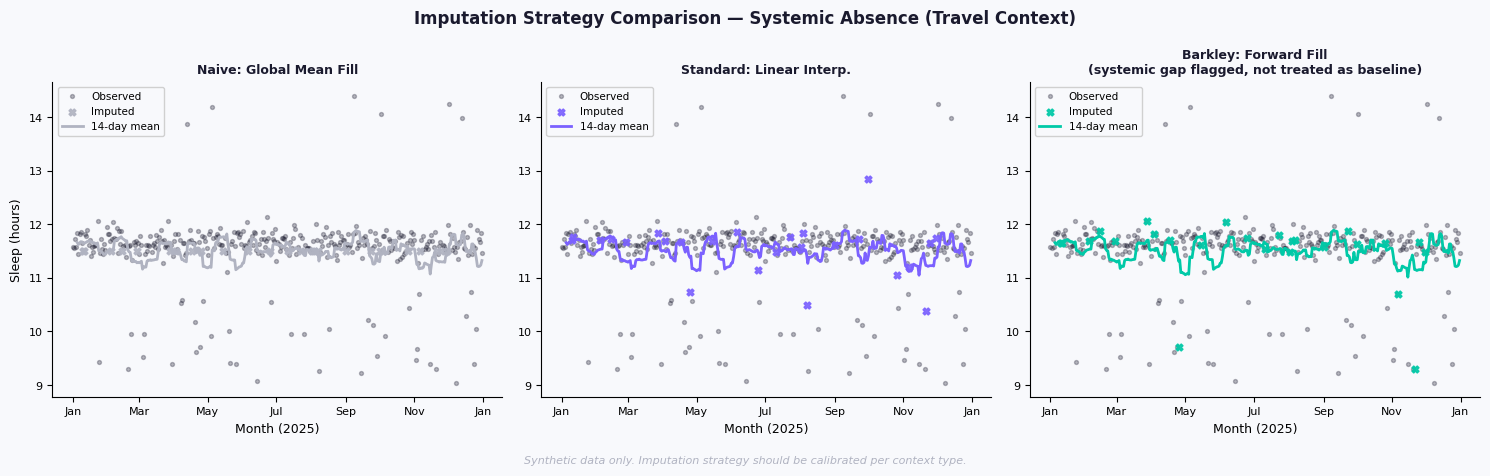

In [4]:
travel_dog_id = df[df["context"] == "travel"]["dog_id"].iloc[0]
travel_dog = df[df["dog_id"] == travel_dog_id].set_index("date").sort_index()
signal = travel_dog["sleep_hours"].copy()
missing_mask = travel_dog["data_missing"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Imputation Strategy Comparison — Systemic Absence (Travel Context)",
             fontsize=12, fontweight="bold", color=COLORS["primary"])

strategies = [
    ("Naive: Global Mean Fill",     signal.fillna(signal.mean()),         COLORS["neutral"]),
    ("Standard: Linear Interp.",    signal.interpolate(method="time"),    COLORS["accent"]),
    ("Barkley: Forward Fill\n(systemic gap flagged, not treated as baseline)",
     signal.ffill().bfill(), COLORS["stable"]),
]

for i, (title, imputed, color) in enumerate(strategies):
    ax = axes[i]
    ax.set_facecolor(COLORS["bg"])
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    true_obs = signal[~missing_mask]
    ax.scatter(true_obs.index, true_obs.values, color=COLORS["primary"], s=8, alpha=0.3, label="Observed")
    imp_at_gaps = imputed[missing_mask]
    ax.scatter(imp_at_gaps.index, imp_at_gaps.values, color=color, s=25, alpha=0.9, marker="X", label="Imputed")
    rolling = imputed.rolling("14D", min_periods=5).mean()
    ax.plot(rolling.index, rolling.values, color=color, linewidth=2, label="14-day mean")
    ax.set_title(title, fontsize=9, fontweight="bold", color=COLORS["primary"])
    ax.set_ylabel("Sleep (hours)" if i == 0 else "", fontsize=9)
    ax.set_xlabel("Month (2025)", fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.9)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
    ax.tick_params(labelsize=8)

fig.text(0.5, -0.03, "Synthetic data only. Imputation strategy should be calibrated per context type.",
         ha="center", fontsize=8, color=COLORS["neutral"], style="italic")
plt.tight_layout()
plt.savefig("../figures/imputation_strategy_comparison.png", dpi=130,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()


## 4. Absence Feature Engineering Across the Cohort

In [5]:
def compute_absence_features(dog_id, df):
    dog = df[df["dog_id"] == dog_id].set_index("date").sort_index()
    total_days   = len(dog)
    missing_days = dog["data_missing"].sum()
    gaps, in_gap, gap_len = [], False, 0
    for is_miss in dog["data_missing"]:
        if is_miss:
            in_gap = True; gap_len += 1
        else:
            if in_gap: gaps.append(gap_len); in_gap = False; gap_len = 0
    if in_gap: gaps.append(gap_len)
    max_gap   = max(gaps) if gaps else 0
    gap_count = len(gaps)
    miss_recs = dog[dog["data_missing"]]
    systemic_contexts = ["travel", "boarding", "owner_absent"]
    systemic_rate = (miss_recs["context"].isin(systemic_contexts)).mean() if len(miss_recs) > 0 else 0
    obs = dog[~dog["data_missing"]]
    if "nocturnal_restlessness" in obs.columns and len(obs) > 0:
        streak, max_quiet = 0, 0
        for val in (obs["nocturnal_restlessness"] > 2.0).astype(int):
            if val == 0: streak += 1; max_quiet = max(max_quiet, streak)
            else: streak = 0
    else: max_quiet = 0
    return {
        "dog_id": dog_id, "breed": dog["breed"].iloc[0],
        "has_drift": dog["has_drift"].iloc[0],
        "missing_rate": round(missing_days / total_days, 4),
        "gap_count": gap_count, "max_gap_days": max_gap,
        "systemic_absence_rate": round(systemic_rate, 3),
        "max_quiet_streak": max_quiet,
    }

all_dogs = df["dog_id"].unique()
absence_features = pd.DataFrame([compute_absence_features(d, df) for d in all_dogs])
print("Absence features computed for all dogs.")
print()
print("Feature means by group (has_drift):")
print(absence_features.groupby("has_drift")[
    ["missing_rate","gap_count","max_gap_days","systemic_absence_rate","max_quiet_streak"]
].mean().round(3))


Absence features computed for all dogs.

Feature means by group (has_drift):
           missing_rate  gap_count  max_gap_days  systemic_absence_rate  \
has_drift                                                                 
False             0.072     24.469         1.963                  0.534   
True              0.070     23.895         1.947                  0.582   

           max_quiet_streak  
has_drift                    
False               144.605  
True                115.737  


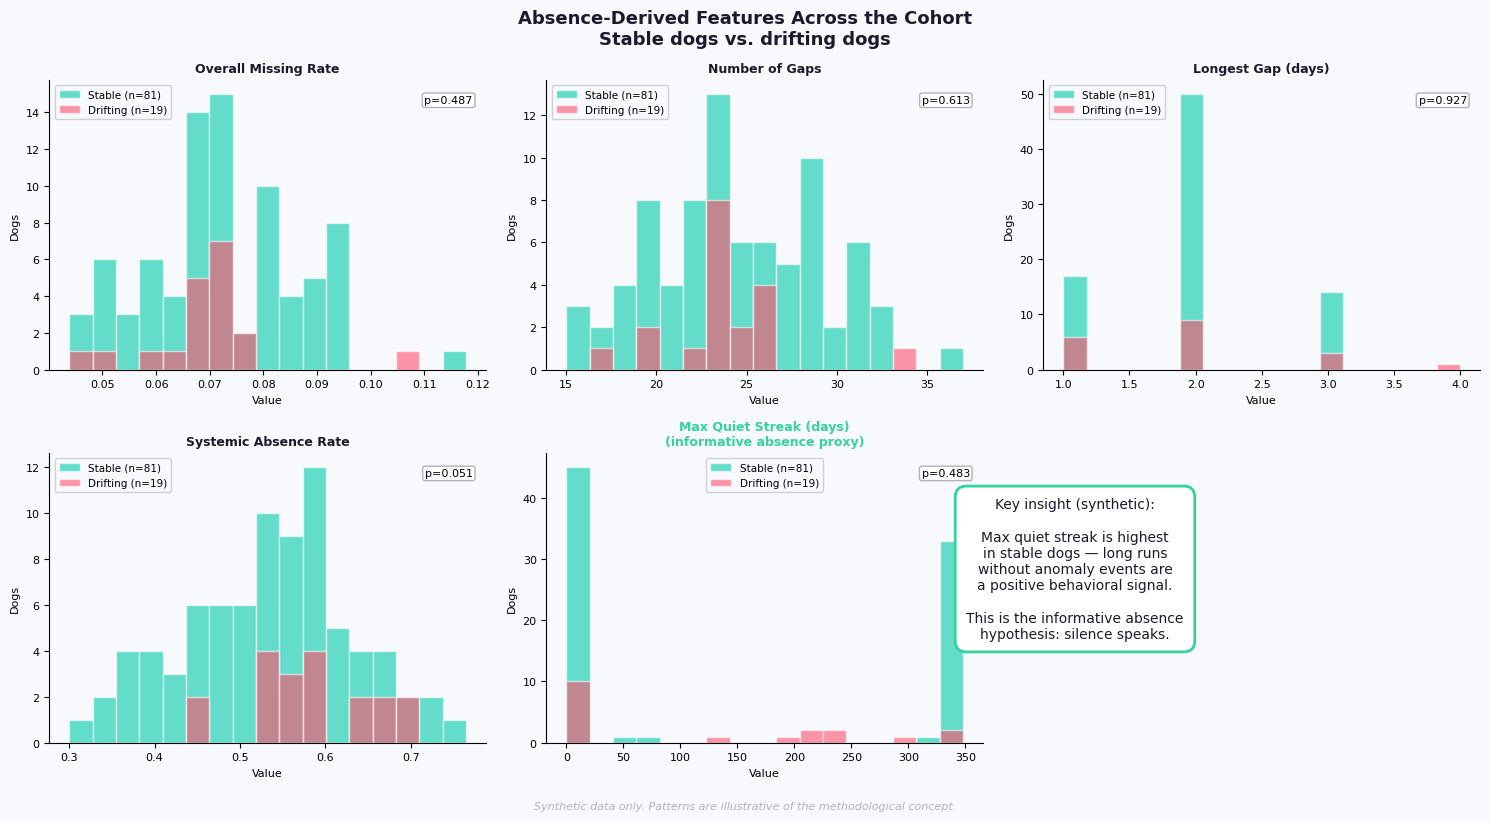

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Absence-Derived Features Across the Cohort\nStable dogs vs. drifting dogs",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

feature_specs = [
    ("missing_rate",          "Overall Missing Rate",           False),
    ("gap_count",             "Number of Gaps",                 False),
    ("max_gap_days",          "Longest Gap (days)",             False),
    ("systemic_absence_rate", "Systemic Absence Rate",          False),
    ("max_quiet_streak",      "Max Quiet Streak (days)\n(informative absence proxy)", True),
]

stable   = absence_features[~absence_features["has_drift"]]
drifting = absence_features[absence_features["has_drift"]]

for idx, (feat, label, is_key) in enumerate(feature_specs):
    row, col = divmod(idx, 3)
    ax = axes[row][col]
    ax.set_facecolor(COLORS["bg"])
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    s_vals = stable[feat].dropna()
    d_vals = drifting[feat].dropna()
    bins = np.linspace(min(s_vals.min(), d_vals.min()), max(s_vals.max(), d_vals.max()), 18)
    ax.hist(s_vals,  bins=bins, color=COLORS["stable"], alpha=0.6,
            label=f"Stable (n={len(s_vals)})", edgecolor="white")
    ax.hist(d_vals,  bins=bins, color=COLORS["signal"], alpha=0.6,
            label=f"Drifting (n={len(d_vals)})", edgecolor="white")
    t_stat, p_val = stats.ttest_ind(s_vals, d_vals)
    ax.set_title(label, fontsize=9, fontweight="bold",
                 color=COLORS["info_abs"] if is_key else COLORS["primary"])
    ax.set_xlabel("Value", fontsize=8); ax.set_ylabel("Dogs", fontsize=8)
    ax.legend(fontsize=7.5, framealpha=0.9); ax.tick_params(labelsize=8)
    ax.text(0.97, 0.92, f"p={p_val:.3f}{'*' if p_val < 0.05 else ''}",
            transform=ax.transAxes, fontsize=8, ha="right",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=COLORS["neutral"]))

axes[1][2].set_visible(False)
fig.text(0.72, 0.28,
    "Key insight (synthetic):\n\n"
    "Max quiet streak is highest\nin stable dogs — long runs\n"
    "without anomaly events are\na positive behavioral signal.\n\n"
    "This is the informative absence\nhypothesis: silence speaks.",
    fontsize=10, color=COLORS["primary"],
    bbox=dict(boxstyle="round,pad=0.8", fc="white", ec=COLORS["info_abs"], linewidth=2),
    ha="center", va="center"
)

fig.text(0.5, -0.02, "Synthetic data only. Patterns are illustrative of the methodological concept.",
         ha="center", fontsize=8, color=COLORS["neutral"], style="italic")
plt.tight_layout()
plt.savefig("../figures/absence_features_cohort.png", dpi=130,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()


## Summary

This notebook demonstrated the Barkley Missing Data Paradox with synthetic data.

| Standard assumption | Barkley position |
|---|---|
| Missing data = noise to eliminate | Missing data has structure and behavioral meaning |
| All gaps treated equivalently | Gaps classified: systemic, dropout, informative |
| Impute to preserve completeness | Encode informative absence as a feature |
| Absence = unknown | Extended anomaly-free periods = positive stability signal |

### The Three-Category Framework Applied

1. **Systemic absence** → context-tagged, imputed with context-aware strategy
2. **Sensor dropout** → short-gap interpolation
3. **Informative absence** → encoded as `quiet_streak`, not imputed

---

### The Complete Technical Thesis

| Notebook | Pillar | Implication |
|----------|--------|-------------|
| 01 | Individual baseline > breed average | Reference frame matters |
| 02 | Temporal drift > snapshot | Direction matters, not just position |
| 03 | Absence encoding > imputation | Silence can speak |

---

> **Research note:** All analysis uses synthetic data. See [`docs/ethics_and_limitations.md`](../docs/ethics_and_limitations.md).
